# Mean-curvature energy: accuracy and fitted preferences

Restore the saved mean-curvature energy models and the matched zero-mask FiLM reference. Compare held-out physical mean-curvature MSE overall, by size, and by the new distance-first anatomical regions. Crypt interiors are s<0.75 irrespective of neck shape and are split by whether their assigned interior contains LGR5; necks require 0.75≤s<1.1 plus a qualifying circumference profile; villus starts at s=1.1. Unqualified boundary cells and missing annotations remain explicit categories.

Inspect center preferences, affine-logN pair amplitudes, the exact signed 1:½ hop ratio, learned saturation, accommodation and cross-fold sign agreement. The model minimizes a graph surrogate energy, not a surface Helfrich energy: parameters do not measure bending moduli or pressure. Predictions never use measured neighboring curvature or patch areas. All metrics, node predictions, coefficient tables, figures and a report are saved beside the training artifacts. No fitting takes place here.

Role: analysis; restore models, evaluate predictions and inspect coefficients.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').exists())  # Project root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import copy
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython
from IPython.display import display
from src.artifacts.bundle import load_bundle
from src.artifacts.runs import AnalysisRun
from src.artifacts.provenance import workflow_fingerprint
from src.training.coupled_fit import graph_samples
from src.models.coupled_fate import normalized_tanh
from src.inference.predict import predict_targets
from src.analysis.spatial.regions import distance_regions
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
torch.set_num_threads(4)


## Analysis settings
Select the saved run and coefficient view before any inference. Regional definitions are explicit and written to the analysis settings file.

In [2]:
# Saved models and execution
TRAINING_RUN = 'logN_signed_half_hop_20260929_145842'  # Completed run under training_results/mean_curvature_energy_training.
OUTPUT_TAG = 'mean_energy_evaluation'  # Analysis output subfolder.
COMPARE_PREVIOUS = True  # Include the earlier mean-only model with unrestricted hop amplitudes.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # FiLM and energy inference device; earlier unrestricted models retain CPU inference.

# Region definitions
CRYPT_MAX = .75  # Crypt interior: s below this value, regardless of neck profile.
NECK_MAX = 1.1  # Neck upper bound; villus includes this boundary and larger distances.
CRYPT_MARKER = 'LGR5'  # Any positive interior cell determines the assigned crypt subtype.

# Figures and conditional uncertainty
READOUT_MODEL = 'learned_accommodated'  # Main energy model whose coefficients are displayed.
READOUT_FOLD = 0  # One fitted coefficient convention for pair panels.
N_POINTS = 60  # Number of size values in coefficient curves.
BOOTSTRAP_DRAWS = 2000  # Paired held-out organoid bootstrap draws; no retraining uncertainty.
BOOTSTRAP_SEED = 42  # Reproducible bootstrap draws.


## Restore models and anatomical annotations
Verify saved folds and build node-aligned regions directly from the source graph distances and circumference profiles. Crypt subtype uses the exclusive identities of this experiment. No annotations are loaded from an unrelated analysis.

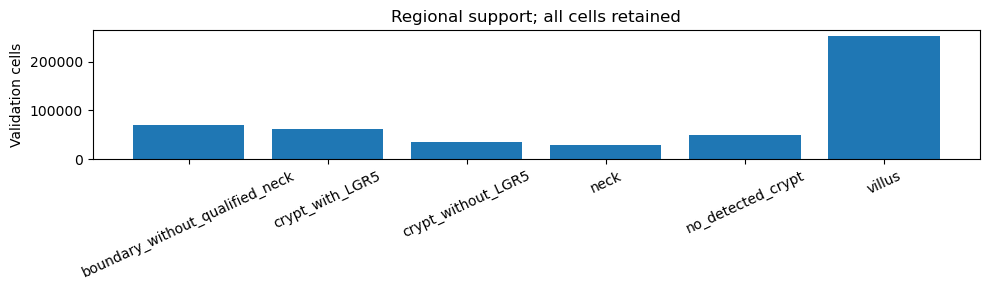

In [3]:
run=AnalysisRun(PROJECT_ROOT/'training_results/mean_curvature_energy_training'/TRAINING_RUN)
if not (run.directory/'complete.json').exists():raise ValueError('Training has not completed')
records=run.records;membership=json.loads((run.directory/'splits.json').read_text());cohort=load_bundle(run.directory/'cohort')
marker_names=cohort['all_marker_names'];identity_names=marker_names+['Unassigned']
source=AnalysisRun(run.settings['source_run'])
if membership!=json.loads((source.directory/'splits.json').read_text()):raise ValueError('Source fold mismatch')
OUTPUT_DIR=run.directory/'analysis'/OUTPUT_TAG;OUTPUT_DIR.mkdir(parents=True,exist_ok=True);(OUTPUT_DIR/'predictions').mkdir(exist_ok=True)
settings=dict(training_run=str(run.directory),compare_previous=COMPARE_PREVIOUS,crypt_max=CRYPT_MAX,neck_max=NECK_MAX,crypt_marker=CRYPT_MARKER,
    energy_device=DEVICE,energy_solver_rtol=1e-11,neck_minimum_cells=0,readout_model=READOUT_MODEL,readout_fold=READOUT_FOLD,n_points=N_POINTS,bootstrap_draws=BOOTSTRAP_DRAWS,bootstrap_seed=BOOTSTRAP_SEED,
    code_sha256=workflow_fingerprint(PROJECT_ROOT/'experiments/benchmarks/mean_curvature_energy_evaluation.ipynb'),catalog_sha256=hashlib.sha256((run.directory/'models.json').read_bytes()).hexdigest())
(OUTPUT_DIR/'settings.json').write_text(json.dumps(settings,indent=2))
annotations={};region_tables=[]
for split in membership:
    data=load_bundle(run.directory/f'inputs/fold_{split["fold"]}_mean')
    for g in data['groups']['val']:
        raw=copy.deepcopy(cohort['raw_graphs'][g.organoid_str]);raw.x=g.x.clone()
        table=distance_regions(raw,PROJECT_ROOT/'training_data'/run.settings['dataset'],marker_names=marker_names,
            crypt_marker=CRYPT_MARKER,crypt_max=CRYPT_MAX,neck_max=NECK_MAX)
        annotations[g.organoid_str]=table.region.to_numpy();region_tables.append(table)
regions=pd.concat(region_tables,ignore_index=True);regions.to_csv(OUTPUT_DIR/'regions.csv.gz',index=False)
support=regions.groupby('region').agg(cells=('node','size'),organoids=('organoid_str','nunique')).reset_index()
support.to_csv(OUTPUT_DIR/'regional_support.csv',index=False)
fig,ax=plt.subplots(figsize=(10,3));ax.bar(support.region,support.cells);ax.tick_params(axis='x',rotation=25);ax.set(ylabel='Validation cells',title='Regional support; all cells retained');fig.tight_layout();plt.show()


## Predict held-out organoids
Restore every model and baseline. FiLM predictions are inverse-transformed to physical residual units; all methods use exactly the same physical target array. Save full-curvature predictions and verify that regional errors reconstruct each organoid’s total error.

Energy inference uses the selected CPU/CUDA backend and can load the previously saved CPU-fitted checkpoints directly. GPU inference uses the same float64 energy and a certified sparse solve; measured target values are removed before prediction.

In [4]:
scores=[];audits=[]
for split in membership:
    fold=split['fold'];physical=load_bundle(run.directory/f'inputs/fold_{fold}_mean');graphs=physical['groups']['val']
    flat=copy.deepcopy(graphs)
    for g in flat:g.y=g.y.reshape(-1)
    samples=graph_samples(flat,2)
    jobs=[r._asdict() for r in records[records.fold==fold].itertuples(index=False)]
    if COMPARE_PREVIOUS:
        old=source.records[(source.records.fold==fold)&(source.records.name=='mean_learned_N_coupled')]
        if len(old)!=1:raise ValueError('Ambiguous previous model')
        r=old.iloc[0].to_dict();r.update(name='previous_free_hops',family='previous',bundle=str(source.directory/r['bundle']));jobs.append(r)
    jobs.append(dict(name='Baseline',key=f'baseline_f{fold}',family='baseline'))
    for row in jobs:
        name=row['name'];predictions=[]
        if row['family']=='film':
            model=load_bundle(run.directory/row['bundle'])['model'];inputs=load_bundle(run.directory/row['input_bundle'])
            if [g.organoid_str for g in inputs['groups']['val']]!=split['validation']:raise ValueError('FiLM validation order mismatch')
            _,pred,_=predict_targets(inputs['groups']['val'],model,target_transform=inputs['transform'],device=DEVICE)
            start=0
            for g in graphs:predictions.append(np.asarray(pred)[start:start+len(g.x)].reshape(-1));start+=len(g.x)
        elif row['family']=='baseline':predictions=[np.zeros(len(g.x)) for g in graphs]
        else:
            model=load_bundle(Path(row['bundle']) if row['family']=='previous' else run.directory/row['bundle'])['model']
            features=[{k:v for k,v in s.items() if k!='y'} for s in samples]
            predictions=model.predict_samples(features,device=DEVICE) if row['family']=='energy' else [model.predict_sample(s).reshape(-1) for s in features]
        offsets=[0];truths=[];saved=[];ids=[]
        for g,pred in zip(graphs,predictions):
            residual=g.y.numpy().reshape(-1);offset=np.asarray(physical['baseline_offsets'][g.organoid_str]).reshape(-1)
            if not np.isfinite(pred).all():raise ValueError('Nonfinite predictions')
            error=(pred-residual)**2;region=annotations[g.organoid_str];reconstructed=0.
            for label in ['total',*np.unique(region)]:
                take=np.ones(len(error),bool) if label=='total' else region==label
                mse=float(error[take].mean());scores.append(dict(name=name,fold=fold,organoid_str=g.organoid_str,N=len(g.x),region=label,mse=mse))
                if label!='total':reconstructed+=mse*take.sum()/len(error)
            if not np.isclose(reconstructed,error.mean(),rtol=1e-10,atol=1e-12):raise ValueError('Regions fail to reconstruct total')
            ids.append(g.organoid_str);offsets.append(offsets[-1]+len(g.x));truths.append(residual+offset);saved.append(pred+offset)
        np.savez_compressed(OUTPUT_DIR/'predictions'/f"{row['key']}.npz",prediction=np.concatenate(saved),truth=np.concatenate(truths),offsets=offsets,organoid_ids=np.asarray(ids))
        audits.append(dict(key=row['key'],fold=fold,finite=True,regional_reconstruction=True));print('Evaluated',row['key'],flush=True)
scores=pd.DataFrame(scores);scores.to_csv(OUTPUT_DIR/'validation_mse.csv',index=False)
summary=scores.groupby(['name','region']).mse.agg(['mean','sem','count']).reset_index();summary.to_csv(OUTPUT_DIR/'mse_summary.csv',index=False)
(OUTPUT_DIR/'prediction_audit.json').write_text(json.dumps(audits,indent=2))


Evaluated film_mean_d2_f0_s42


Evaluated center_local_f0_s42


Evaluated center_accommodated_f0_s42


Evaluated linear_accommodated_f0_s42


Evaluated learned_local_f0_s42


...

Evaluated center_local_f4_s42


Evaluated center_accommodated_f4_s42


Evaluated mean_learned_N_coupled_f4_s42


Evaluated baseline_f4


4687

## Accuracy overall, by region and by size
MSE is averaged equally across organoids; regional means use organoids containing that region. Bands indicate one organoid SEM, not retraining uncertainty. All curves compare mean curvature in the same physical units.

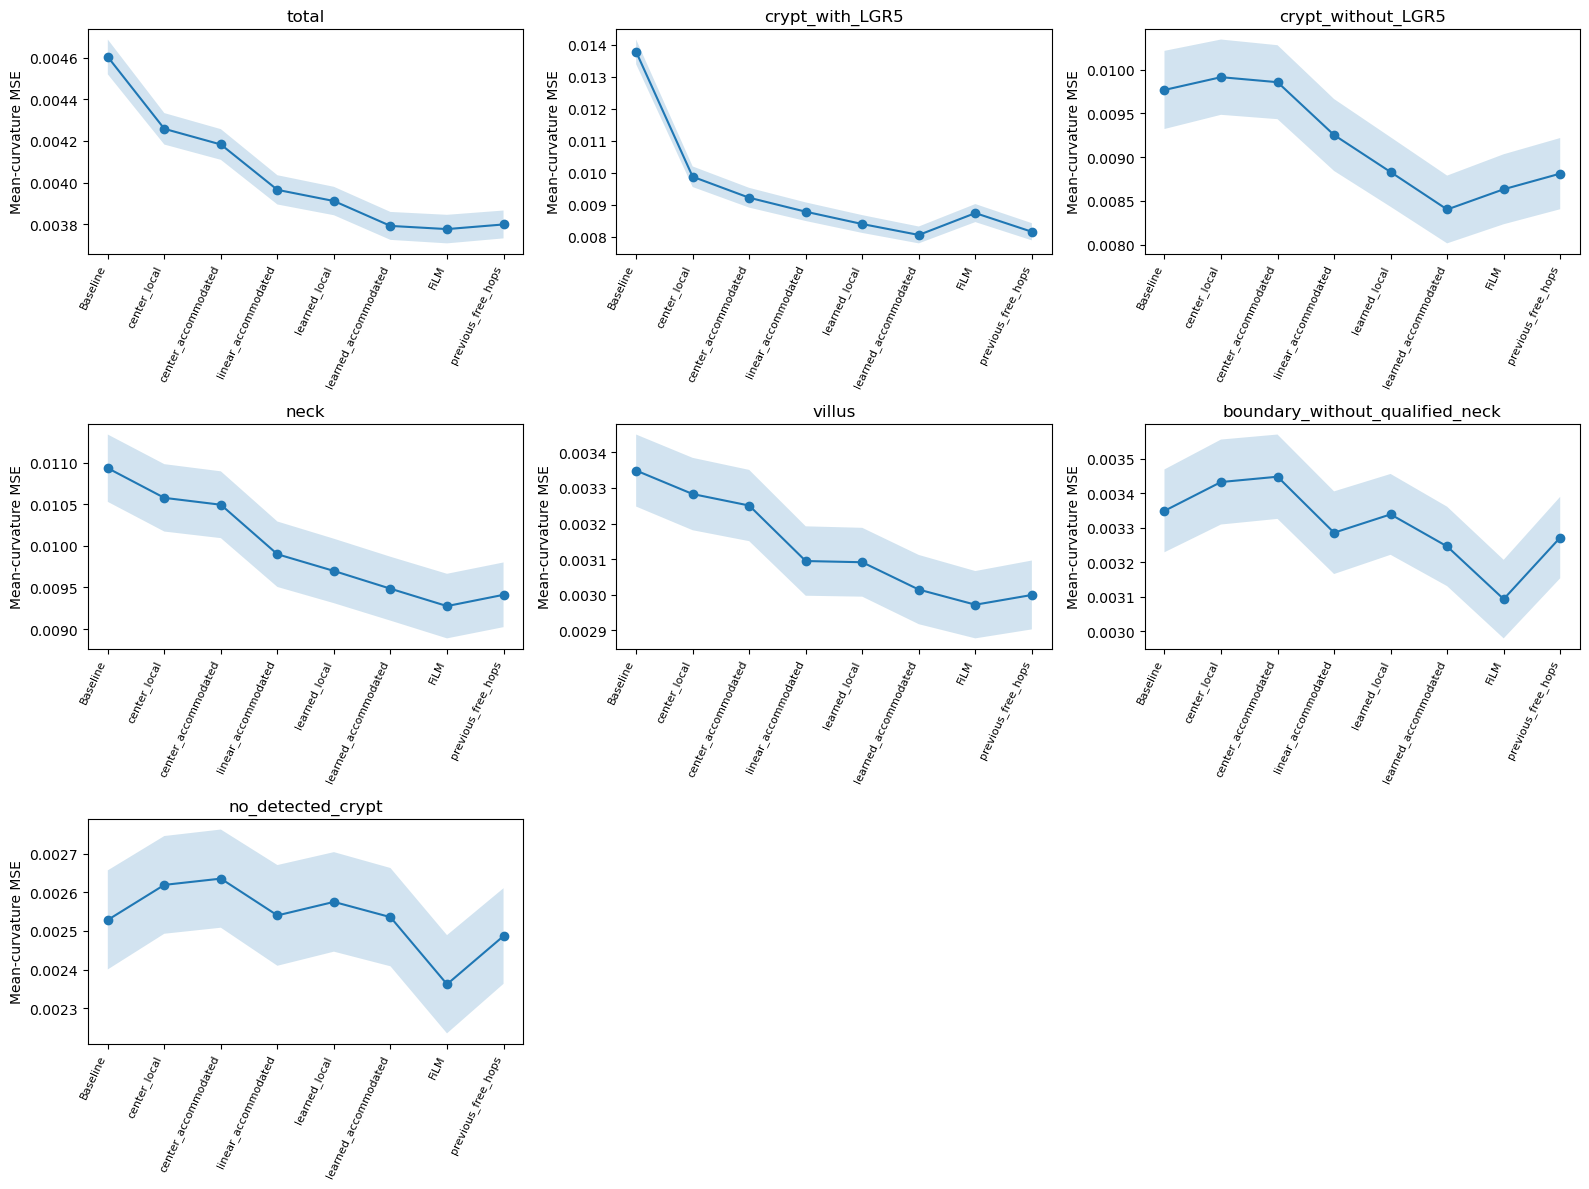

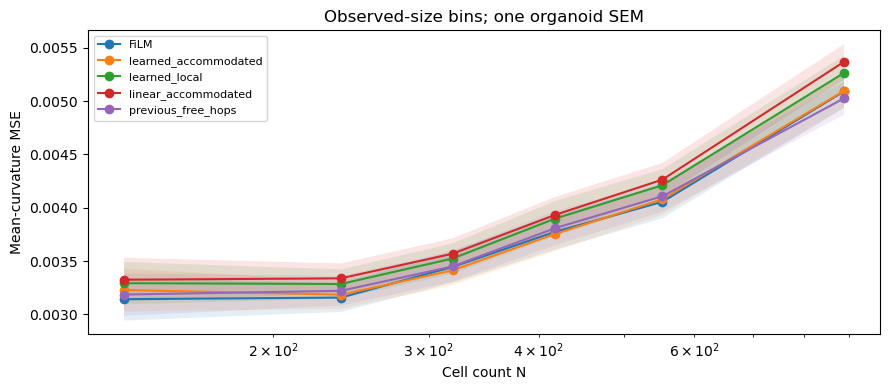

In [5]:
order=['Baseline','center_local','center_accommodated','linear_accommodated','learned_local','learned_accommodated','FiLM']+(['previous_free_hops'] if COMPARE_PREVIOUS else [])
order=[name for name in order if name in set(summary.name)]
labels=[label for label in ['total','crypt_with_LGR5','crypt_without_LGR5','neck','villus','boundary_without_qualified_neck','no_detected_crypt','annotation_unavailable'] if label in set(summary.region)]
fig,axes=plt.subplots(int(np.ceil(len(labels)/3)),3,figsize=(16,4*int(np.ceil(len(labels)/3))),squeeze=False)
for ax,label in zip(axes.flat,labels):
    rows=summary[summary.region==label].set_index('name').reindex(order);x=np.arange(len(order))
    ax.plot(x,rows['mean'],'o-');ax.fill_between(x,rows['mean']-rows['sem'],rows['mean']+rows['sem'],alpha=.2)
    ax.set_xticks(x,order,rotation=65,ha='right',fontsize=8);ax.set(title=label,ylabel='Mean-curvature MSE')
for ax in list(axes.flat)[len(labels):]:ax.set_visible(False)
fig.tight_layout();fig.savefig(OUTPUT_DIR/'mse_by_region.png',dpi=160);plt.show()
main_names=['FiLM','learned_accommodated','learned_local','linear_accommodated']+(['previous_free_hops'] if COMPARE_PREVIOUS else [])
total=scores[scores.region=='total'].copy();unique=total.drop_duplicates('organoid_str');edges=np.unique(np.quantile(unique.N,np.linspace(0,1,7)))
total['size_bin']=pd.cut(total.N,edges,include_lowest=True);size_table=total.groupby(['name','size_bin'],observed=True).agg(N=('N','mean'),mean=('mse','mean'),sem=('mse','sem'),count=('mse','size')).reset_index()
size_table.to_csv(OUTPUT_DIR/'mse_by_size.csv',index=False)
fig,ax=plt.subplots(figsize=(9,4))
for name in main_names:
    d=size_table[size_table.name==name];ax.plot(d.N,d['mean'],'o-',label=name);ax.fill_between(d.N,d['mean']-d['sem'],d['mean']+d['sem'],alpha=.12)
ax.set(xscale='log',xlabel='Cell count N',ylabel='Mean-curvature MSE',title='Observed-size bins; one organoid SEM');ax.legend(fontsize=8);fig.tight_layout();fig.savefig(OUTPUT_DIR/'mse_by_size.png',dpi=160);plt.show()
rng=np.random.default_rng(BOOTSTRAP_SEED);paired=[]
for reference_name in ['FiLM','linear_accommodated','learned_local','previous_free_hops']:
    if reference_name not in set(total.name):continue
    a=total[total.name==READOUT_MODEL].set_index('organoid_str').mse;b=total[total.name==reference_name].set_index('organoid_str').mse
    delta=(a-b).dropna().to_numpy();draws=np.array([rng.choice(delta,len(delta),replace=True).mean() for _ in range(BOOTSTRAP_DRAWS)])
    paired.append(dict(model=READOUT_MODEL,reference=reference_name,difference=delta.mean(),ci_low=np.quantile(draws,.025),ci_high=np.quantile(draws,.975),organoids=len(delta)))
pd.DataFrame(paired).to_csv(OUTPUT_DIR/'paired_comparisons.csv',index=False)


## Fitted preferences, accommodation and hop amplitudes
Center preferences and activation are constant across N. Only the pair amplitudes and accommodation vary with log N. Show one fold’s pair coefficients and all folds’ accommodation curves; export every energy-model coefficient. Amplitudes are training-centered response coefficients, not isolated-cell curvatures or measured mechanical forces.

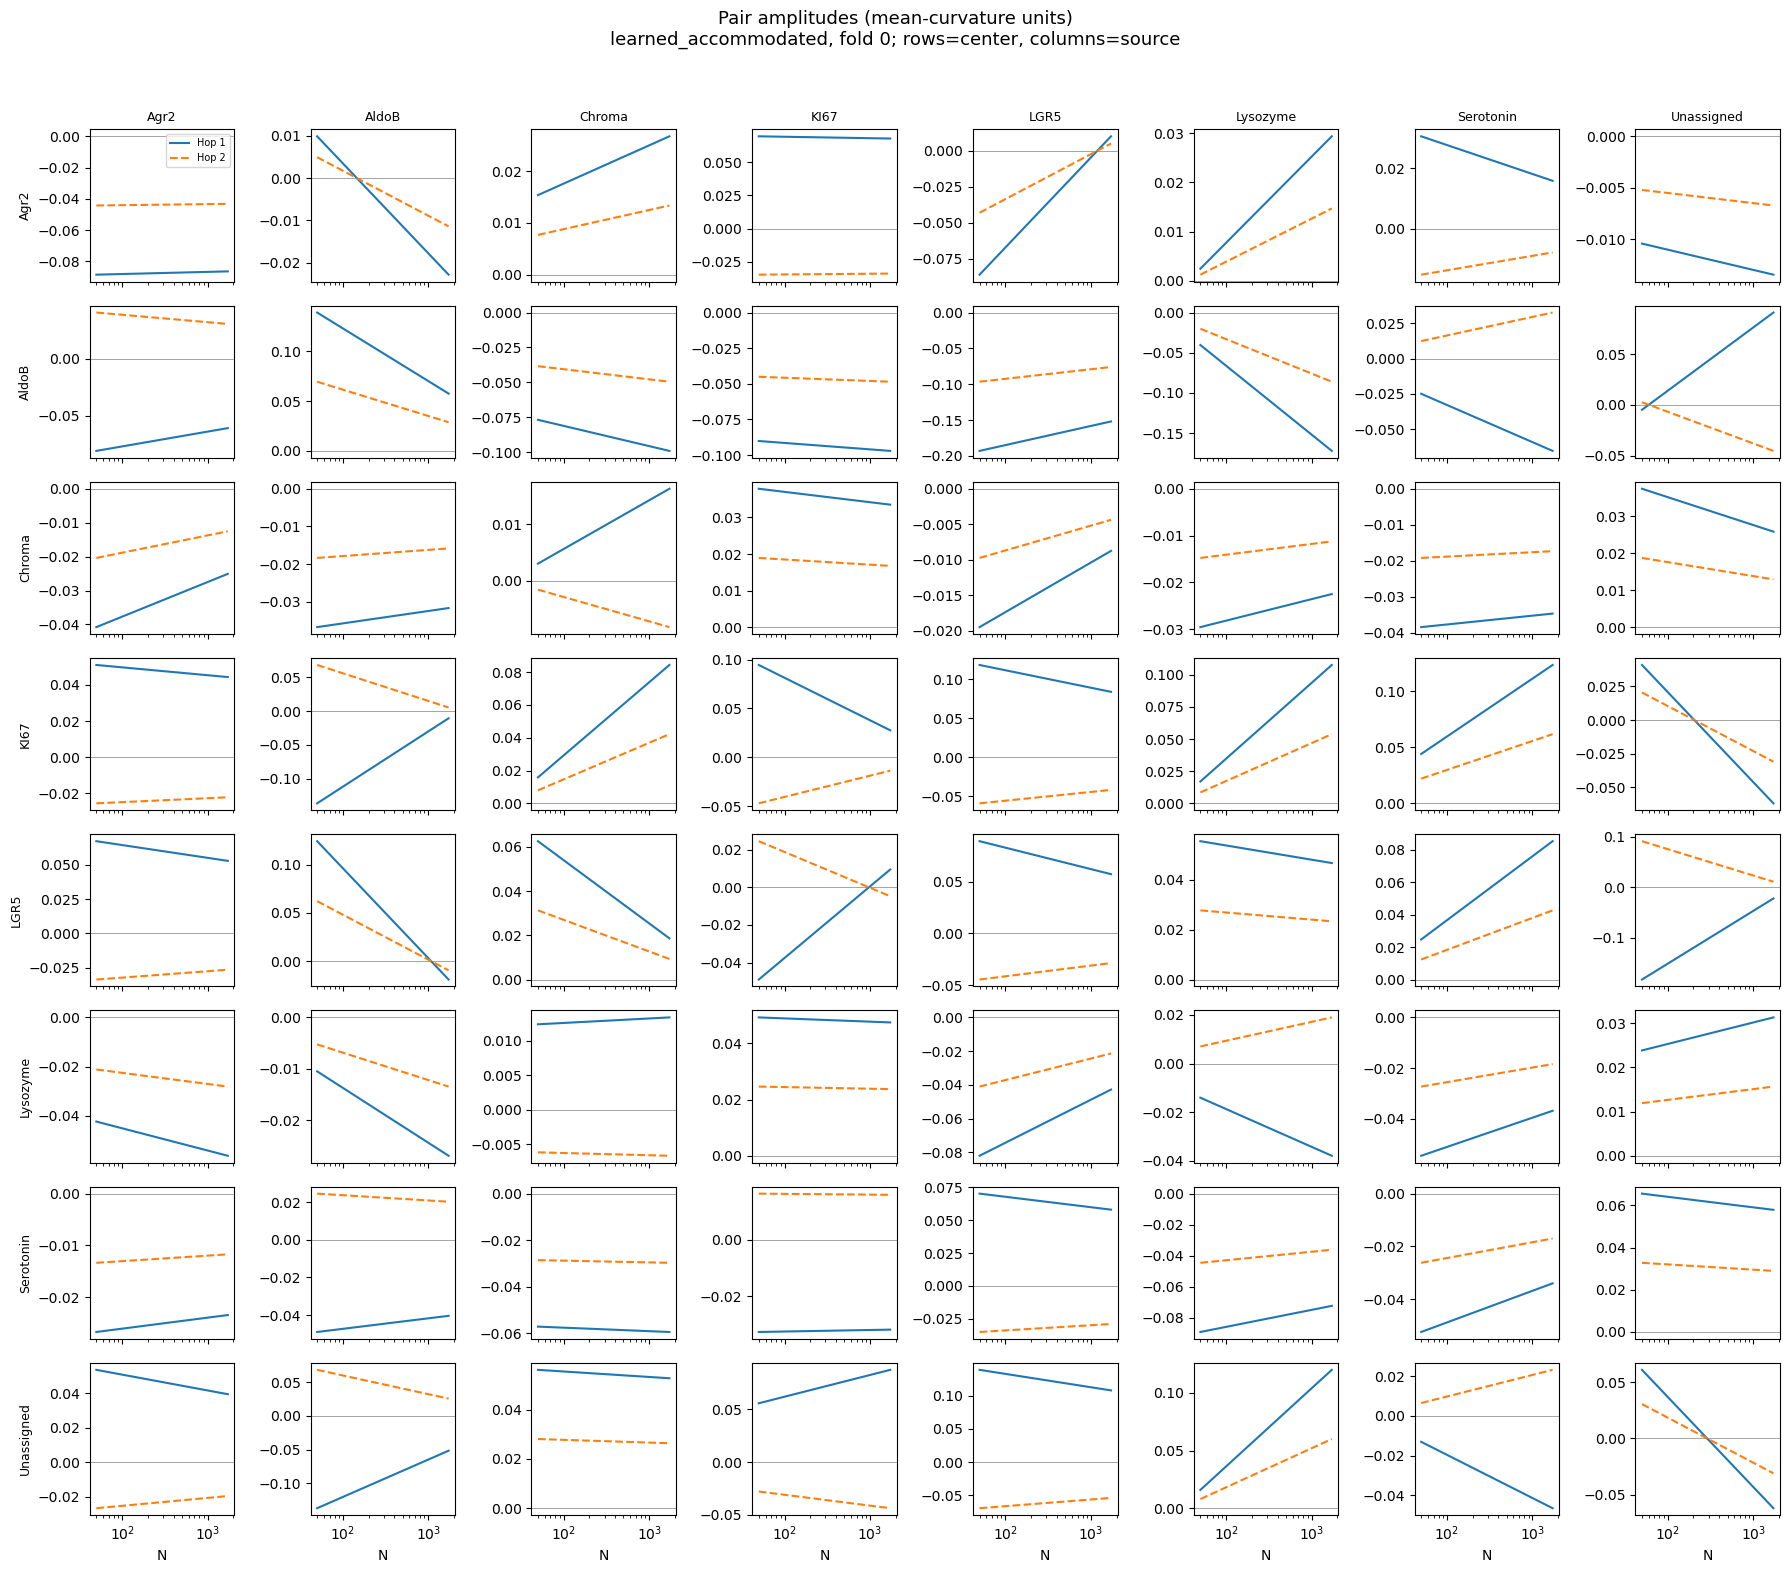

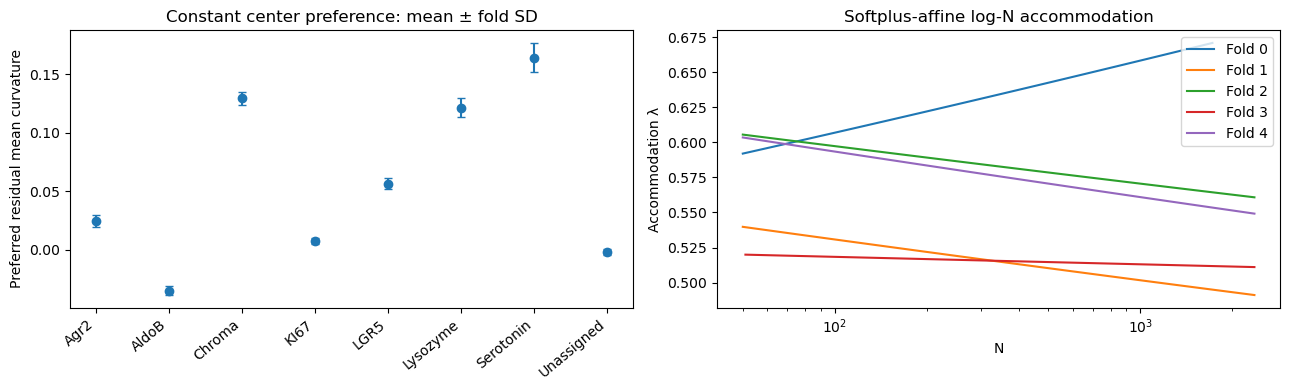

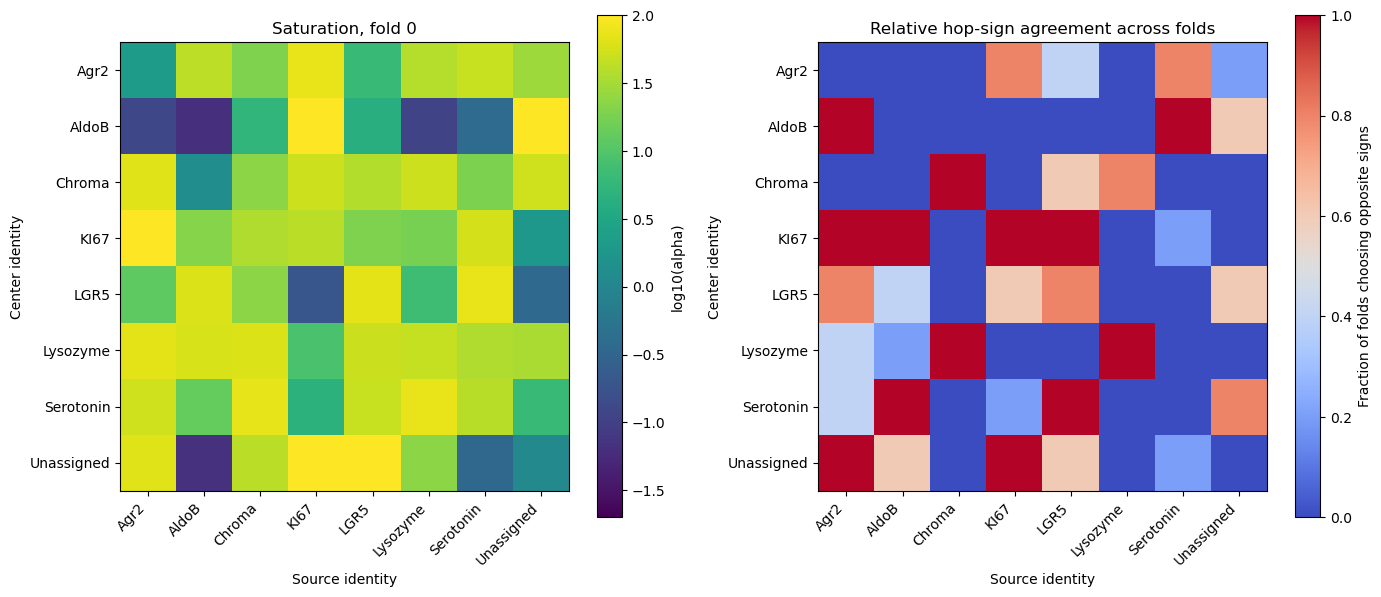

In [6]:
coefficients=[];centers=[];saturation=[];accommodation=[];readout=None
for row in records[records.family=='energy'].itertuples():
    model=load_bundle(run.directory/row.bundle)['model'];ns=np.geomspace(*np.exp(model.log_count_range.numpy()),N_POINTS);co=model.coefficients(ns)
    if not np.allclose(abs(co['hop2']),.5*abs(co['hop1']),rtol=1e-12,atol=1e-12):raise ValueError('Hop ratio violated')
    for a,center in enumerate(identity_names):
        centers.append(dict(name=row.name,fold=row.fold,center=center,preference=co['center'][0,a]))
        if model.pairs:
            for b,source_name in enumerate(identity_names):
                saturation.append(dict(name=row.name,fold=row.fold,center=center,source=source_name,alpha=co['alpha'][a,b],relative_sign=int(model.signs[a,b]),support=int(model.pair_support[a,b]),fitted=bool(model.active_pairs[a,b]) and model.activation=='learned',sign_fitted=bool(model.active_pairs[a,b])))
                for i,n in enumerate(ns):coefficients.append(dict(name=row.name,fold=row.fold,N=n,center=center,source=source_name,hop1=co['hop1'][i,a,b],hop2=co['hop2'][i,a,b]))
    accommodation.extend(dict(name=row.name,fold=row.fold,N=n,strength=value) for n,value in zip(ns,co['accommodation']))
    if row.name==READOUT_MODEL and row.fold==READOUT_FOLD:readout=(model,ns,co)
for filename,data in [('pair_amplitudes',coefficients),('center_preferences',centers),('saturation_and_signs',saturation),('accommodation',accommodation)]:pd.DataFrame(data).to_csv(OUTPUT_DIR/f'{filename}.csv',index=False)
model,ns,co=readout;t=len(identity_names)
fig,axes=plt.subplots(t,t,figsize=(18,16),sharex=True)
for a in range(t):
    for b in range(t):
        ax=axes[a,b];ax.plot(ns,co['hop1'][:,a,b],label='Hop 1');ax.plot(ns,co['hop2'][:,a,b],label='Hop 2',ls='--');ax.axhline(0,color='gray',lw=.5);ax.set_xscale('log')
        if a==0:ax.set_title(identity_names[b],fontsize=9)
        if b==0:ax.set_ylabel(identity_names[a],fontsize=9)
        if a==t-1:ax.set_xlabel('N')
axes[0,0].legend(fontsize=7);fig.suptitle(f'Pair amplitudes (mean-curvature units)\n{READOUT_MODEL}, fold {READOUT_FOLD}; rows=center, columns=source',fontsize=13);fig.tight_layout(rect=(0,0,1,.96));fig.savefig(OUTPUT_DIR/'pair_amplitudes.png',dpi=140);plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,4));c=pd.DataFrame(centers);c=c[c.name==READOUT_MODEL].groupby('center').preference.agg(['mean','std']).reindex(identity_names)
axes[0].errorbar(np.arange(t),c['mean'],yerr=c['std'],fmt='o',capsize=3);axes[0].set_xticks(np.arange(t),identity_names,rotation=40,ha='right');axes[0].set(ylabel='Preferred residual mean curvature',title='Constant center preference: mean ± fold SD')
a=pd.DataFrame(accommodation)
for fold,d in a[a.name==READOUT_MODEL].groupby('fold'):axes[1].plot(d.N,d.strength,label=f'Fold {fold}')
axes[1].set(xscale='log',xlabel='N',ylabel='Accommodation λ',title='Softplus-affine log-N accommodation');axes[1].legend();fig.tight_layout();fig.savefig(OUTPUT_DIR/'preferences_and_accommodation.png',dpi=160);plt.show()
sat=pd.DataFrame(saturation);selected=sat[sat.name==READOUT_MODEL];sign=selected.groupby(['center','source']).relative_sign.apply(lambda x:np.mean(x<0)).unstack().reindex(index=identity_names,columns=identity_names)
fig,axes=plt.subplots(1,2,figsize=(14,6));im=axes[0].imshow(np.log10(co['alpha']),vmin=np.log10(.02),vmax=2,cmap='viridis');fig.colorbar(im,ax=axes[0],label='log10(alpha)')
im=axes[1].imshow(sign,vmin=0,vmax=1,cmap='coolwarm');fig.colorbar(im,ax=axes[1],label='Fraction of folds choosing opposite signs')
for ax,title in zip(axes,[f'Saturation, fold {READOUT_FOLD}','Relative hop-sign agreement across folds']):
    ax.set_xticks(np.arange(t),identity_names,rotation=45,ha='right');ax.set_yticks(np.arange(t),identity_names);ax.set(title=title,xlabel='Source identity',ylabel='Center identity')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'saturation_and_signs.png',dpi=160);plt.show()


## Written findings and completion audit
Summarize model changes, physical-unit accuracy and coefficient stability. Confidence intervals condition on fitted models. The sign search is coordinate-wise, and folds have overlapping training data, so agreement is descriptive rather than independent replication.

In [7]:
overall=summary[summary.region=='total'].set_index('name');best=overall.loc[READOUT_MODEL,'mean'];film=overall.loc['FiLM','mean']
stability=selected.groupby(['center','source']).agg(alpha_min=('alpha','min'),alpha_max=('alpha','max'),opposite_folds=('relative_sign',lambda x:int((x<0).sum())),folds=('fold','nunique'))
stability.to_csv(OUTPUT_DIR/'pair_stability.csv')
variable=int((stability.alpha_max/stability.alpha_min>10).sum());disagree=int(((stability.opposite_folds>0)&(stability.opposite_folds<stability.folds)).sum());bound=int(((selected.alpha<=.0201)|(selected.alpha>=99)).sum())
table=['| Model | Mean-curvature MSE | Organoid SEM |','| --- | ---: | ---: |']
for name in order:
    row=overall.loc[name];table.append(f"| {name} | {row['mean']:.6f} | {row['sem']:.6f} |")
comparisons='\n'.join(f"- Main model minus {r['reference']}: {r['difference']:+.3g}, conditional 95% CI [{r['ci_low']:+.3g}, {r['ci_high']:+.3g}]." for r in paired)
improvements=[]
for name,description in [('linear_accommodated','linear interactions with accommodation'),('learned_local','learned interactions without accommodation')]:
    if name in overall.index:improvements.append(f"{100*(best/overall.loc[name,'mean']-1):+.2f}% MSE relative to {description}")
regional=summary.pivot(index='region',columns='name',values='mean')
regional_notes=[]
for region in ['crypt_with_LGR5','crypt_without_LGR5','neck','villus']:
    if region in regional.index:
        change=100*(regional.loc[region,READOUT_MODEL]/regional.loc[region,'FiLM']-1)
        regional_notes.append(f"{region}: {change:+.2f}%")
preferences=pd.read_csv(OUTPUT_DIR/'center_preferences.csv');preferences=preferences[preferences.name==READOUT_MODEL]
highest=preferences.loc[preferences.groupby('fold').preference.idxmax(),'center'].value_counts()
lowest=preferences.loc[preferences.groupby('fold').preference.idxmin(),'center'].value_counts()
accom=pd.read_csv(OUTPUT_DIR/'accommodation.csv');accom=accom[accom.name==READOUT_MODEL]
increasing=sum(d.sort_values('N').strength.iloc[-1]>d.sort_values('N').strength.iloc[0] for _,d in accom.groupby('fold'))
report=f"""# Mean-curvature preferences with signed half-amplitude second hops

Completed {len(records)} trained models on {len(membership)} identical saved outer folds, with {total.organoid_str.nunique()} held-out organoids. No measured neighboring curvature or cell-patch area enters predictions.

## Accuracy

The learned accommodated model has MSE **{best:.6f}**, versus **{film:.6f}** for the fresh matching mean-curvature FiLM: **{100*(best/film-1):+.2f}%** relative MSE. All scores use physical mean-curvature units and equal organoid weighting.

{chr(10).join(table)}

{comparisons}

Negative paired differences favor the new main model. Intervals condition on fitted models; they exclude retraining uncertainty and are exploratory.

## Main findings

**Contributions of saturation and accommodation:** {'; '.join(improvements)}. Negative changes favor the main model. Read these differences alongside the paired intervals above. The FiLM and previous-model comparisons do not constitute formal equivalence tests.

**Regional accuracy.** Relative MSE changes against FiLM are {', '.join(regional_notes)}. Negative values favor the energy model. These are descriptive regional comparisons; region means weight organoids equally within each region, so they cannot be averaged directly to recover total MSE. All cells are included in the total score.

**Center preferences.** {highest.index[0]} has the highest preferred residual mean curvature in {int(highest.iloc[0])}/{len(membership)} folds; {lowest.index[0]} has the lowest in {int(lowest.iloc[0])}/{len(membership)}. These preferences include the fitted reference neighborhood and the baseline convention, so they do not isolate intrinsic cell shape.

**Accommodation versus size.** Its fitted strength increases with N in {increasing}/{len(membership)} folds. Its values span approximately {accom.strength.min():.2f}–{accom.strength.max():.2f} over the plotted fitting ranges. Inspect these fold-specific trends separately from the prediction gains. This fitted relative strength is not a measured material modulus or proof of a developmental change in mechanics.

## What changed

The new model minimizes equal-cell preference error plus a shared adjacent-cell squared-difference penalty. It solves `(I+lambda*L)h=u`, with an unnormalized undirected graph Laplacian. The old implementation used degree-weighted preference accommodation. The new energy is a surrogate, not a fitted surface Helfrich energy or absolute bending modulus.

Center preferences and saturation are constant across N. Hop-1 pair amplitudes are affine in log(N/N_ref); lambda is softplus-affine. Hop 2 equals exactly ±0.5 times hop 1. Each ordered pair's relative sign is constant across N and selected from training data through multistart alternating optimization. The sign search reaches a coordinate-wise optimum, not a guaranteed global optimum. Both hops change sign together if their shared amplitude crosses zero. The coefficient ratio does not impose a ratio on total ring contributions. Fate interactions use two-hop neighborhoods, but the accommodation solve can propagate their effects across the whole connected graph; the depth-2 FiLM comparison is an accuracy reference, not a matched receptive-field experiment.

Pair responses use the normalized tanh of source fraction in the whole two-hop neighborhood, multiplied by source shares in each ring. Response means and coefficient contrast conventions are fitted on training organoids. The hop-1 table has weighted zero row/column means; hop 2 is derived and has no independent constraints. These conventions do not establish causal cellular interactions. Center preferences describe a fitted reference neighborhood after baseline subtraction; they are not direct measurements of isolated cells' intrinsic curvature.

## Coefficient stability

Across the main model's folds, {disagree}/{len(stability)} pairs select different relative hop signs; {variable}/{len(stability)} span more than tenfold in saturation. {bound}/{len(selected)} saturation estimates approach a bound. Coefficient confidence is not established by prediction quality or sign agreement alone; inspect support and response curves before interpreting thresholds.

## Data and fairness

All models reuse the previously saved mean-curvature cleanup, baseline, exclusive fates and exact outer folds. Baselines retain the earlier organoid-level global inputs, including geometry; there are no cell-patch area weights and no geometry inputs to the fate models. Center controls retain the size-dependent global baseline. N dependence is restricted to pair amplitudes and accommodation within the new fate model.

FiLM is freshly trained on mean curvature with depth 2, width 128, zero masking and the original reference's optimizer, dropout, edge loss and inner early-stopping protocol. It has only log N in its global head vector. Its model-specific asinh transform is inverted before scoring; energy fitting uses physical residuals scaled internally for numerical stability. FiLM uses its inner early-stop partition, while energy refits the full outer training fold after penalty selection. Neither selects using outer validation targets. The previous unrestricted mean-only model is an accuracy comparator, not a controlled single-change ablation.

## Regions and figures

Crypt interiors have s<0.75 independent of neck shape and are subdivided by any exclusive LGR5-positive cell in that crypt's assigned interior. Necks require 0.75≤s<1.1 and a local minimum or flat circumference section; no additional crypt-cell-count filter is imposed. Villus has s≥1.1 independent of neck qualification. Unqualified boundary, missing annotations and no-detected-crypt remain explicit categories. Original nearest-crypt assignments are retained.

- [Regional and total MSE](analysis/{OUTPUT_TAG}/mse_by_region.png).
- [MSE versus observed size](analysis/{OUTPUT_TAG}/mse_by_size.png).
- [Pair amplitudes](analysis/{OUTPUT_TAG}/pair_amplitudes.png).
- [Center preferences and accommodation](analysis/{OUTPUT_TAG}/preferences_and_accommodation.png).
- [Saturation and hop-sign agreement](analysis/{OUTPUT_TAG}/saturation_and_signs.png).

The executed evaluation notebook and CSV/NPZ exports contain the complete results. All fitted models, copied baselines, transformations, training/validation memberships and settings are saved in this run.
"""
(run.directory/'REPORT.md').write_text(report)
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),evaluations=len(audits),all_hop_ratios_verified=True,regional_reconstruction=True),indent=2))
print('Report:',run.directory/'REPORT.md',flush=True)


Report: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/mean_curvature_energy_training/logN_signed_half_hop_20260929_145842/REPORT.md
